<a href="https://colab.research.google.com/github/Dripp234/AIML/blob/main/Day7_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

# Find the actual data file within the downloaded directory
data_file = None
for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            data_file = os.path.join(root, file)
            break
    if data_file:
        break

if data_file:
    df_twitter = pd.read_csv(data_file)
    print(f"Loaded data from: {data_file}")
else:
    print("No CSV file found in the dataset directory.")
    df_twitter = pd.DataFrame() # Create an empty DataFrame if no CSV is found

display(df_twitter.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Loaded data from: /kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv


,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
df_twitter.columns = ['tweet_id', 'entity', 'sentiment', 'tweet_text']
display(df_twitter.head())
display(df_twitter.info())

,tweet_id,entity,sentiment,tweet_text
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    999 non-null    int64 
 1   entity      999 non-null    object
 2   sentiment   999 non-null    object
 3   tweet_text  999 non-null    object
dtypes: int64(1), object(3)
memory usage: 31.3+ KB


None

/tmp/ipykernel_521/2230727882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_twitter, palette='viridis')


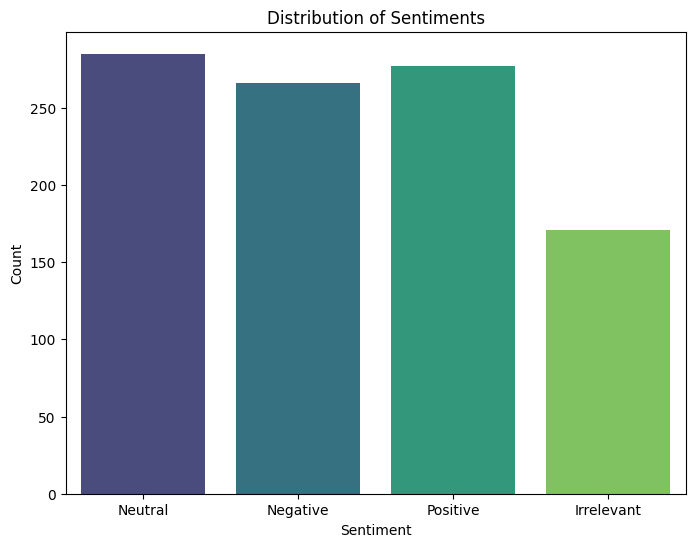

,count
sentiment,
Neutral,285
Positive,277
Negative,266
Irrelevant,171


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df_twitter, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

display(df_twitter['sentiment'].value_counts())

The sentiment distribution appears to be relatively balanced. Now, I will preprocess the text data by cleaning it and then prepare it for model training. This will involve converting text to lowercase, removing punctuation, and then vectorizing the text using TF-IDF.

In [ ]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Text Preprocessing
def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    return text

df_twitter['cleaned_text'] = df_twitter['tweet_text'].apply(preprocess_text)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency
X = tfidf_vectorizer.fit_transform(df_twitter['cleaned_text'])
y = df_twitter['sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing and splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data preprocessing and splitting complete.
X_train shape: (799, 5000)
X_test shape: (200, 5000)


The text data has been preprocessed and vectorized, and the dataset has been split into training and testing sets. Now, I will train a Multinomial Naive Bayes classifier, which is a common choice for text classification tasks, and then evaluate its performance using accuracy and a classification report.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Train the Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.5150

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.67      0.06      0.11        34
    Negative       0.51      0.74      0.60        53
     Neutral       0.61      0.39      0.47        57
    Positive       0.47      0.71      0.57        56

    accuracy                           0.52       200
   macro avg       0.57      0.47      0.44       200
weighted avg       0.56      0.52      0.47       200



The previous Multinomial Naive Bayes model achieved an accuracy of 0.5150. Let's try a Logistic Regression model to see if we can improve the performance.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_logreg = logreg_model.predict(X_test)

# Evaluate the Logistic Regression model
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
report_logreg = classification_report(y_test, y_pred_logreg)

print(f"Logistic Regression Model Accuracy: {accuracy_logreg:.4f}")
print("\nLogistic Regression Classification Report:")
print(report_logreg)

Logistic Regression Model Accuracy: 0.5050

Logistic Regression Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.57      0.12      0.20        34
    Negative       0.55      0.66      0.60        53
     Neutral       0.45      0.54      0.49        57
    Positive       0.52      0.55      0.53        56

    accuracy                           0.51       200
   macro avg       0.52      0.47      0.45       200
weighted avg       0.51      0.51      0.48       200



Let's create a testing module to manually input a sentence and predict its sentiment.

In [ ]:
def predict_sentiment(text, model, vectorizer, preprocessor):
    # Preprocess the input text
    cleaned_text = preprocessor(text)
    # Vectorize the cleaned text
    text_vectorized = vectorizer.transform([cleaned_text])
    # Predict the sentiment
    sentiment = model.predict(text_vectorized)[0]
    return sentiment

# Example usage:
input_sentence = "This movie was absolutely fantastic and I loved every minute of it!"
predicted_sentiment = predict_sentiment(input_sentence, logreg_model, tfidf_vectorizer, preprocess_text)
print(f"Input: '{input_sentence}'")
print(f"Predicted Sentiment: {predicted_sentiment}")

input_sentence_2 = "I am so disappointed with the service today, it was terrible."
predicted_sentiment_2 = predict_sentiment(input_sentence_2, logreg_model, tfidf_vectorizer, preprocess_text)
print(f"\nInput: '{input_sentence_2}'")
print(f"Predicted Sentiment: {predicted_sentiment_2}")


Input: 'This movie was absolutely fantastic and I loved every minute of it!'
Predicted Sentiment: Positive

Input: 'I am so disappointed with the service today, it was terrible.'
Predicted Sentiment: Positive
